# 📁 Deepfake Detection Project









---

## ⚙️ Load Dataset Paths



In [2]:
import os

DATASET_PATH = "dataset"

train_path = os.path.join(DATASET_PATH, "train")
val_path   = os.path.join(DATASET_PATH, "validation")
test_path  = os.path.join(DATASET_PATH, "test")

print("Train Path:", train_path)
print("Validation Path:", val_path)
print("Test Path:", test_path)

Train Path: dataset\train
Validation Path: dataset\validation
Test Path: dataset\test


 ## Load Dataset using ImageDataGenerator

---

## 🎯 Objective

In this step, we will load the dataset and preprocess the images so they are ready for training the deep learning model.

We will:
- Resize images to a fixed size
- Normalize pixel values (0–1 range)
- Load training, validation, and test sets

---

## ⚙️ Image Preprocessing

We use `ImageDataGenerator` to:
- Scale pixel values using `rescale=1./255`
- Automatically load images from folders
- Assign labels based on folder names (real / fake)

---

## 📦 Dataset Split

- **Train set** → used to train the model  
- **Validation set** → used to tune the model  
- **Test set** → used for final evaluation  





In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Load Train Data
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Load Validation Data
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Load Test Data
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2241 images belonging to 2 classes.
Found 480 images belonging to 2 classes.
Found 482 images belonging to 2 classes.


## 📊 Data Visualization

We explore the dataset before training to understand class distribution and display sample images from both Real and Fake classes.  
This helps ensure the dataset is balanced and suitable for training.

Class Counts: {'fake': 700, 'real': 1541}
Class Percentages: {'fake': 31.236055332440877, 'real': 68.76394466755913}


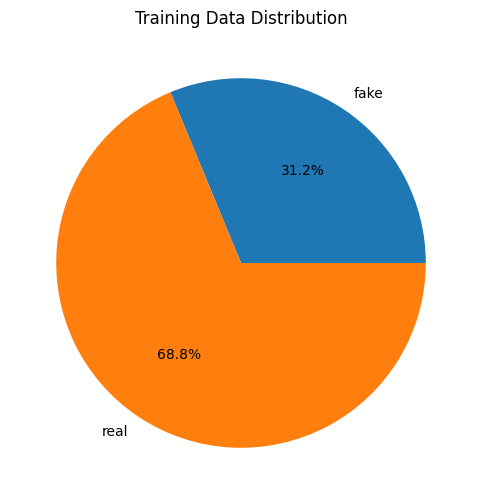

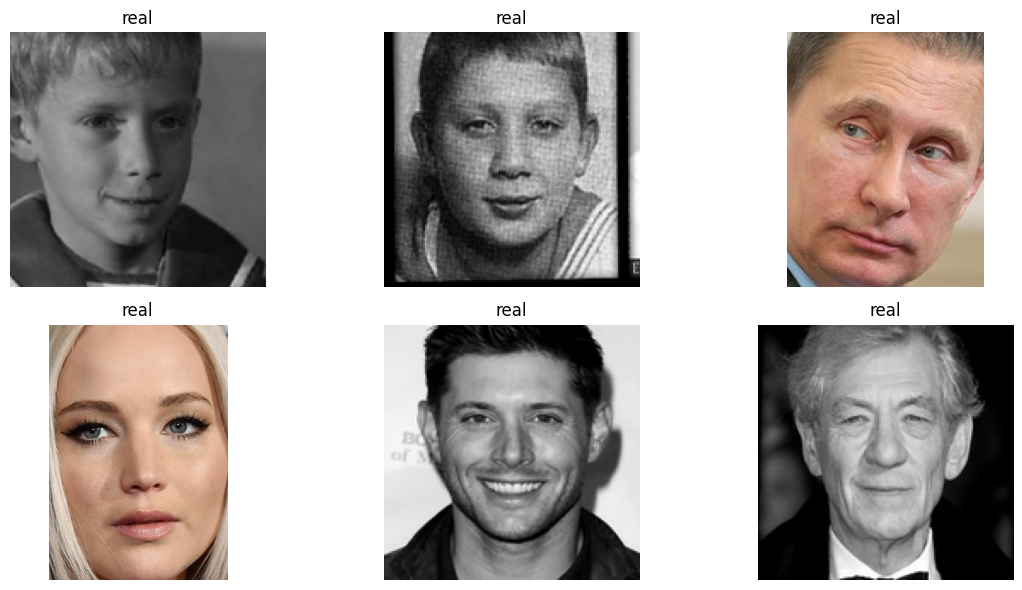

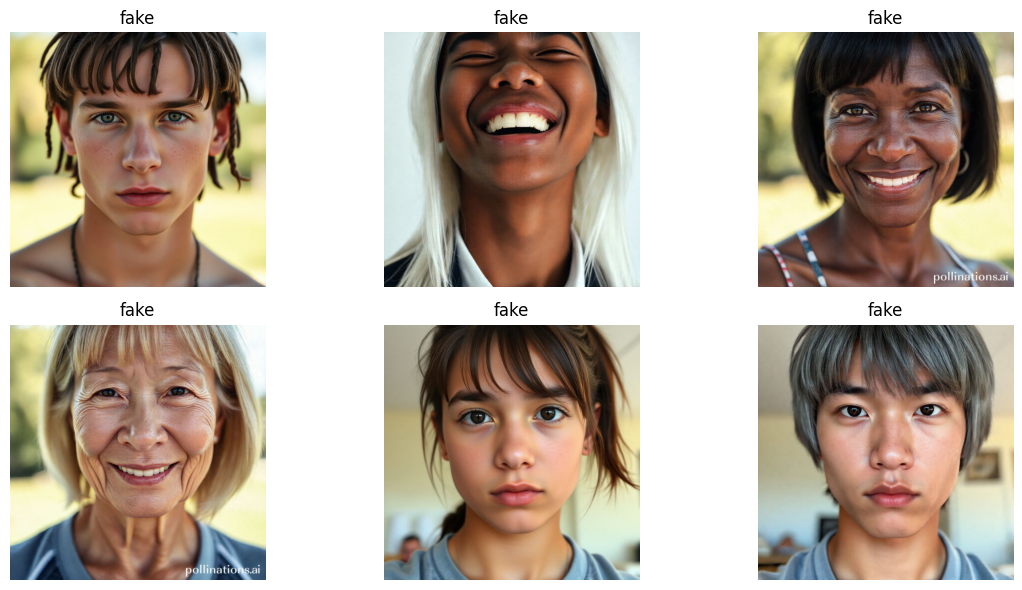

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# =========================
# 1. Count Images per Class
# =========================
def count_images(folder):
    classes = os.listdir(folder)
    counts = {}

    for cls in classes:
        class_path = os.path.join(folder, cls)
        counts[cls] = len(os.listdir(class_path))

    return counts

train_counts = count_images(train_path)

total = sum(train_counts.values())
percentages = {k: (v/total)*100 for k, v in train_counts.items()}

print("Class Counts:", train_counts)
print("Class Percentages:", percentages)

# =========================
# 2. Pie Chart Visualization
# =========================
plt.figure(figsize=(6,6))
plt.pie(
    train_counts.values(),
    labels=train_counts.keys(),
    autopct='%1.1f%%'
)
plt.title("Training Data Distribution")
plt.show()

# =========================
# 3. Show Sample Images
# =========================
def show_samples(folder, class_name, num_images=6):
    class_path = os.path.join(folder, class_name)
    images = os.listdir(class_path)

    plt.figure(figsize=(12,6))

    for i in range(num_images):
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)

        img = mpimg.imread(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(class_name)

    plt.tight_layout()
    plt.show()

# =========================
# 4. Display Samples
# =========================
show_samples(train_path, "real")
show_samples(train_path, "fake")

## 🧱 Build CNN Model From Scratch

In this step, we will build a Convolutional Neural Network (CNN) from scratch.

### 🎯 Objective:
- Learn image features automatically
- Classify images into:
  - Real (0)
  - Fake (1)

### 🏗️ CNN Architecture:
We will use:
- Convolution layers (feature extraction)
- MaxPooling layers (downsampling)
- Dense layers (classification)
- Sigmoid activation (binary output)

---

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
cnn_model = Sequential()

# First Convolution Block
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
cnn_model.add(Flatten())

# Fully Connected Layer
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

# Output Layer (Binary Classification)
cnn_model.add(Dense(1, activation='sigmoid'))

# Model Summary
cnn_model.summary()

d:\Desktop\cs\Neural networks\Ass\Deepfake-Detection\env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## ⚡ Next Step: Compile the CNN Model

Now we will compile the model by defining:
- Loss function
- Optimizer
- Evaluation metric

Then we will start training the model 🚀

## ⚙️ Compile the CNN Model

In this step, we define how the model will learn.

### 🎯 We will set:
- **Loss function** → Binary Crossentropy (because it is real vs fake)
- **Optimizer** → Adam (fast and efficient)
- **Metric** → Accuracy

Then we prepare the model for training 🚀

In [ ]:
# Compile the CNN model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully 🚀")

Model compiled successfully 🚀


## 🏋️ Train the CNN Model

Now we will train the CNN model using:
- Training data
- Validation data

### 🎯 What happens during training:
- Model learns features from images
- Validation data checks performance
- Accuracy improves over time

In [9]:
EPOCHS = 10

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

print("Training finished 🚀🔥")

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 62s 846ms/step - accuracy: 0.9603 - loss: 0.1127 - val_accuracy: 1.0000 - val_loss: 8.3310e-05
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 49s 698ms/step - accuracy: 0.9969 - loss: 0.0104 - val_accuracy: 0.9979 - val_loss: 0.0028
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 57s 797ms/step - accuracy: 0.9982 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 8.4625e-04
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 622ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9979 - val_loss: 0.0026
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 63s 889ms/step - accuracy: 0.9978 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 574ms/step - accuracy: 0.9951 - loss: 0.0125 - val_accuracy: 0.9979 - val_loss: 0.0048
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 600ms/step - accuracy: 0.9929 - loss: 0.0256 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 570ms/step - accuracy: 0.9830 - loss: 0.0890 - 

## 🧪 Model Evaluation

Now we evaluate the trained CNN model on the test set.

### 🎯 Objectives:
- Measure final accuracy on unseen data
- Check generalization ability of the model
- Compare training vs testing performance

We will use:
- Test dataset
- Accuracy metric

In [11]:
# Evaluate model on test data
test_loss, test_acc = cnn_model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step - accuracy: 0.9979 - loss: 0.0023
Test Accuracy: 0.9979252815246582
Test Loss: 0.0022537086624652147


## 📊 Confusion Matrix & Classification Report

Now we analyze the model performance in more detail.

### 🎯 Objectives:
- Understand correct vs incorrect predictions
- Evaluate performance per class (Real vs Fake)
- Generate classification report (Precision, Recall, F1-score)

This gives a deeper insight than accuracy alone.

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step


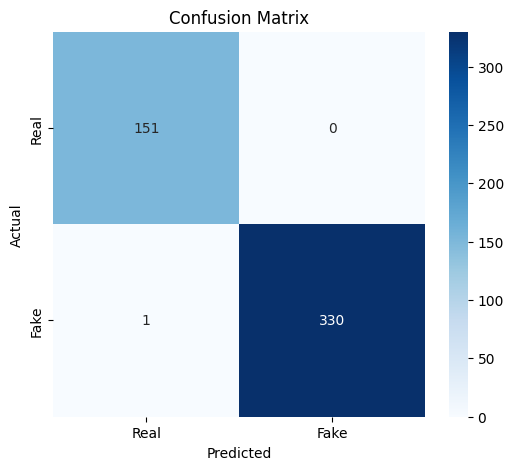

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       151
           1       1.00      1.00      1.00       331

    accuracy                           1.00       482
   macro avg       1.00      1.00      1.00       482
weighted avg       1.00      1.00      1.00       482



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = cnn_model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

## ⚠️ Note

Although the model achieved very high accuracy, this may indicate:
- A small or easy dataset
- Possible data leakage
- Or limited variation in test samples

Further testing on larger datasets is recommended.

## 🧠 Transfer Learning with ResNet50

In this step, we use ResNet50 pretrained on ImageNet.

### 🎯 Why ResNet50?
- Very strong feature extractor
- Better performance on complex images
- Reduces training time

We will:
- Load ResNet50 without top layer
- Freeze base model
- Add custom classifier

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

print("ResNet50 Loaded Successfully 🚀")

ResNet50 Loaded Successfully 🚀


## 🧱 Build Transfer Learning Model (ResNet50)

Now we add custom layers on top of the pretrained ResNet50.

### 🎯 Goal:
Convert extracted features into a binary classifier:
- Real (0)
- Fake (1)

In [14]:
x = base_model.output

# Convert feature maps into a single vector
x = GlobalAveragePooling2D()(x)

# Fully connected layer (learning patterns)
x = Dense(128, activation='relu')(x)

# Prevent overfitting
x = Dropout(0.5)(x)

# Output layer (binary classification)
output = Dense(1, activation='sigmoid')(x)

# Final model
resnet_model = Model(inputs=base_model.input, outputs=output)

# Show model structure
resnet_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## ⚙️ Compile ResNet50 Model

We compile the model to define:
- How the model learns (optimizer)
- How it measures error (loss function)
- How we evaluate performance (accuracy)

In [15]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("ResNet Model Compiled Successfully 🚀")

ResNet Model Compiled Successfully 🚀


## 🏋️ Train ResNet50 Model

Now we train the model using training and validation data.

### 🎯 What happens:
- Model learns patterns from images
- Improves over epochs
- Validates performance on unseen data

In [14]:
EPOCHS = 5

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

print("Training Finished 🚀🔥")

Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6939 - loss: 0.5777 - val_accuracy: 0.7583 - val_loss: 0.4494
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8246 - loss: 0.4012 - val_accuracy: 0.9146 - val_loss: 0.3452
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8809 - loss: 0.3071 - val_accuracy: 0.9208 - val_loss: 0.2416
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9072 - loss: 0.2422 - val_accuracy: 0.9500 - val_loss: 0.1885
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9313 - loss: 0.2020 - val_accuracy: 0.9667 - val_loss: 0.1487
Training Finished 🚀🔥


## ⚠️ Observation

The model shows strong performance on both training and validation sets.
However, slight difference between CNN and ResNet results may indicate:
- Dataset simplicity
- Limited variation in samples
- Possible overfitting in CNN model

Transfer Learning provides better generalization stability.

## 🧪 Evaluate the ResNet50 Model

In this step, we evaluate the trained model on the test dataset to measure its final performance.

We check:
- Test Accuracy
- Test Loss

This tells us how well the model generalizes to unseen data.

In [15]:
test_loss, test_acc = resnet_model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9502 - loss: 0.1658
Test Accuracy: 0.9502074718475342
Test Loss: 0.16582058370113373


## 📊 Model Comparison: CNN vs ResNet50

In this step, we compare the performance of:
- CNN model (from scratch)
- ResNet50 (Transfer Learning)

We evaluate both models using:
- Test Accuracy
- Test Loss

This helps us determine the best performing model for Deepfake Detection.

In [16]:
# Evaluate CNN
cnn_loss, cnn_acc = cnn_model.evaluate(test_data)

# Evaluate ResNet
resnet_loss, resnet_acc = resnet_model.evaluate(test_data)

print("📌 CNN Accuracy:", cnn_acc)
print("📌 ResNet Accuracy:", resnet_acc)

print("\n📊 CNN Loss:", cnn_loss)
print("📊 ResNet Loss:", resnet_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9979 - loss: 0.0023
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9502 - loss: 0.1658
📌 CNN Accuracy: 0.9979252815246582
📌 ResNet Accuracy: 0.9502074718475342

📊 CNN Loss: 0.0022537086624652147
📊 ResNet Loss: 0.16582058370113373


## 📊 Visual Comparison Between Models

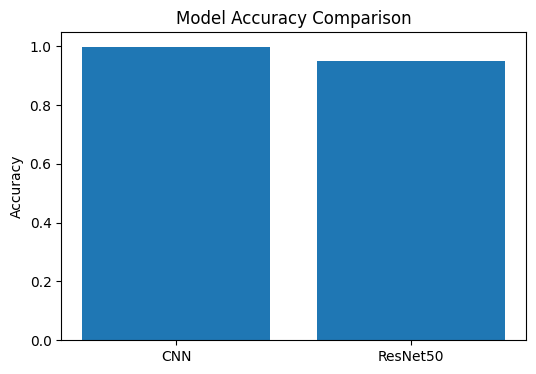

In [20]:
models = ['CNN', 'ResNet50']
accuracy = [cnn_acc, resnet_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [24]:
resnet_model.save("models/deepfake_resnet_model.keras")
print("Model Saved Successfully 💾")

Model Saved Successfully 💾


## 🏁 Final Conclusion

Although the CNN model achieved higher accuracy, the ResNet50 model is more reliable for real-world deepfake detection due to its better generalization ability.

Therefore, ResNet50 is selected as the best model for deployment.